In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
G = nx.florentine_families_graph()

In [3]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")

Number of nodes: 15
Number of edges: 20


In [4]:
degree_dict = dict(G.degree())
degrees = list(degree_dict.values())
density = nx.density(G)
components = list(nx.connected_components(G))

print("KEY METRICS")
print(f"Density: {density:.4f}")
print(f"Connected components: {len(components)}")
print(f"Minimum degree: {min(degrees)}")
print(f"Maximum degree: {max(degrees)}")
print(f"Average degree: {sum(degrees) / len(degrees):.2f}")

KEY METRICS
Density: 0.1905
Connected components: 1
Minimum degree: 1
Maximum degree: 6
Average degree: 2.67


In [5]:
metrics_table = pd.DataFrame({
    "Metric": [
        "Nodes",
        "Edges",
        "Density",
        "Connected Components",
        "Minimum Degree",
        "Maximum Degree",
        "Average Degree"
    ],
    "Value": [
        G.number_of_nodes(),
        G.number_of_edges(),
        round(density, 4),
        len(components),
        min(degrees),
        max(degrees),
        round(sum(degrees) / len(degrees), 2)
    ]
})

print("MAIN METRICS TABLE")
print(metrics_table)

MAIN METRICS TABLE
                 Metric    Value
0                 Nodes  15.0000
1                 Edges  20.0000
2               Density   0.1905
3  Connected Components   1.0000
4        Minimum Degree   1.0000
5        Maximum Degree   6.0000
6        Average Degree   2.6700


In [6]:
degree_table = pd.DataFrame({
    "Family": list(degree_dict.keys()),
    "Degree": list(degree_dict.values())
}).sort_values(by="Degree", ascending=False)

print("DEGREE TABLE")
print(degree_table)

DEGREE TABLE
          Family  Degree
1         Medici       6
4        Strozzi       4
12      Guadagni       4
6        Ridolfi       3
3        Peruzzi       3
7     Tornabuoni       3
2     Castellani       3
11      Bischeri       3
8        Albizzi       3
9       Salviati       2
5      Barbadori       2
0     Acciaiuoli       1
10         Pazzi       1
13        Ginori       1
14  Lamberteschi       1


In [7]:
source = "Medici"
target = "Strozzi"
path = nx.shortest_path(G, source=source, target=target)

print("EXAMPLE PATH")
print(f"Shortest path from {source} to {target}:")
print(" -> ".join(path))

EXAMPLE PATH
Shortest path from Medici to Strozzi:
Medici -> Ridolfi -> Strozzi


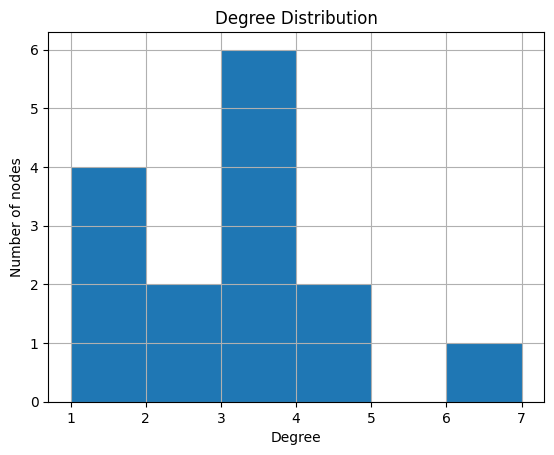

In [8]:
plt.figure()
plt.hist(degrees, bins=range(min(degrees), max(degrees)+2))
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Number of nodes")
plt.grid()
plt.show()

In [9]:
cycles = nx.cycle_basis(G)
example_cycle = cycles[0]

print("CYCLE")
print(" -> ".join(example_cycle + [example_cycle[0]]))

CYCLE
Peruzzi -> Strozzi -> Bischeri -> Peruzzi


In [10]:
print("ADJACENCY LIST")
for node in list(G.nodes())[:5]:
    print(f"{node}: {list(G.neighbors(node))}")

ADJACENCY LIST
Acciaiuoli: ['Medici']
Medici: ['Acciaiuoli', 'Barbadori', 'Ridolfi', 'Tornabuoni', 'Albizzi', 'Salviati']
Castellani: ['Peruzzi', 'Strozzi', 'Barbadori']
Peruzzi: ['Castellani', 'Strozzi', 'Bischeri']
Strozzi: ['Castellani', 'Peruzzi', 'Ridolfi', 'Bischeri']


In [11]:
nodes_subset = list(G.nodes())[:5]
adj_matrix = nx.to_pandas_adjacency(G, nodelist=nodes_subset, dtype=int)

print("ADJACENCY MATRIX")
print(adj_matrix)

ADJACENCY MATRIX
            Acciaiuoli  Medici  Castellani  Peruzzi  Strozzi
Acciaiuoli           0       1           0        0        0
Medici               1       0           0        0        0
Castellani           0       0           0        1        1
Peruzzi              0       0           1        0        1
Strozzi              0       0           1        1        0


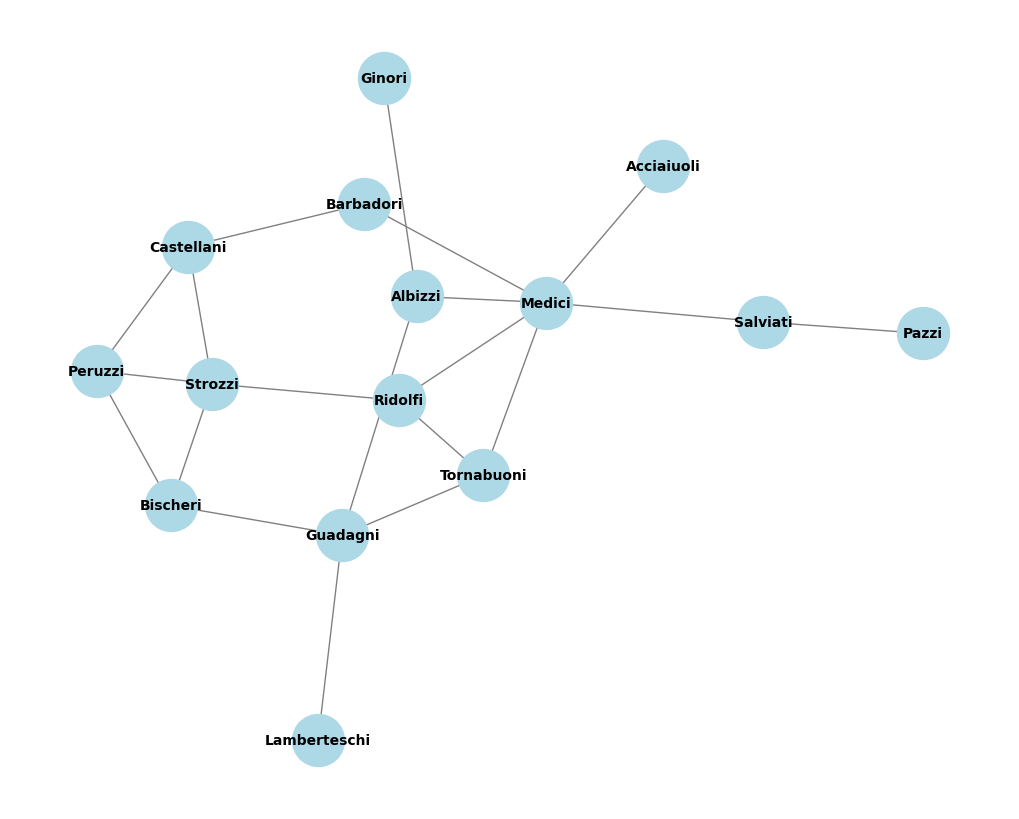

In [12]:
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=1400,
    edge_color="gray",
    font_size=10,
    font_weight="bold"
)

plt.show()

In [15]:
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)
pagerank_centrality = nx.pagerank(G)

In [17]:
avg_clustering = nx.average_clustering(G)

diameter = nx.diameter(G)
avg_shortest_path = nx.average_shortest_path_length(G)

print(f"Average clustering: {avg_clustering:.3f}")
print(f"Diameter: {diameter}")
print(f"Average shortest path length: {avg_shortest_path:.3f}")

Average clustering: 0.160
Diameter: 5
Average shortest path length: 2.486


In [20]:
main_metrics = pd.DataFrame({
    "Metric": [
        "Nodes",
        "Edges",
        "Density",
        "Connected Components",
        "Minimum Degree",
        "Maximum Degree",
        "Average Degree",
        "Average Clustering",
        "Diameter",
        "Average Shortest Path Length"
    ],
    "Value": [
        G.number_of_nodes(),
        G.number_of_edges(),
        round(nx.density(G), 4),
        len(list(nx.connected_components(G))),
        min(degrees),
        max(degrees),
        round(sum(degrees) / len(degrees), 2),
        round(avg_clustering, 4),
        diameter,
        round(avg_shortest_path, 4)
    ]
})

print("MAIN METRICS TABLE")
print(main_metrics)

MAIN METRICS TABLE
                         Metric    Value
0                         Nodes  15.0000
1                         Edges  20.0000
2                       Density   0.1905
3          Connected Components   1.0000
4                Minimum Degree   1.0000
5                Maximum Degree   6.0000
6                Average Degree   2.6700
7            Average Clustering   0.1600
8                      Diameter   5.0000
9  Average Shortest Path Length   2.4857


In [21]:
node_metrics = pd.DataFrame({
    "Family": list(G.nodes()),
    "Degree": [degree_dict[node] for node in G.nodes()],
    "Degree Centrality": [degree_centrality[node] for node in G.nodes()],
    "Betweenness Centrality": [betweenness_centrality[node] for node in G.nodes()],
    "Closeness Centrality": [closeness_centrality[node] for node in G.nodes()],
    "Eigenvector Centrality": [eigenvector_centrality[node] for node in G.nodes()],
    "PageRank": [pagerank_centrality[node] for node in G.nodes()]
}).round(4)

print("NODE METRICS")
print(node_metrics)

NODE METRICS
          Family  Degree  Degree Centrality  Betweenness Centrality  \
0     Acciaiuoli       1             0.0714                  0.0000   
1         Medici       6             0.4286                  0.5220   
2     Castellani       3             0.2143                  0.0549   
3        Peruzzi       3             0.2143                  0.0220   
4        Strozzi       4             0.2857                  0.1026   
5      Barbadori       2             0.1429                  0.0934   
6        Ridolfi       3             0.2143                  0.1136   
7     Tornabuoni       3             0.2143                  0.0916   
8        Albizzi       3             0.2143                  0.2125   
9       Salviati       2             0.1429                  0.1429   
10         Pazzi       1             0.0714                  0.0000   
11      Bischeri       3             0.2143                  0.1044   
12      Guadagni       4             0.2857                  0.2

In [22]:
top5 = node_metrics.sort_values(
    by="Betweenness Centrality", ascending=False
)[["Family", "Betweenness Centrality"]].head(5)

print(top5)
print()

      Family  Betweenness Centrality
1     Medici                  0.5220
12  Guadagni                  0.2546
8    Albizzi                  0.2125
9   Salviati                  0.1429
6    Ridolfi                  0.1136



In [24]:
top_degree = max(degree_dict, key=degree_dict.get)
top_betweenness = max(betweenness_centrality, key=betweenness_centrality.get)

print(f"Family with highest degree: {top_degree} ({degree_dict[top_degree]})")
print(f"Family with highest betweenness: {top_betweenness} ({betweenness_centrality[top_betweenness]:.4f})")

if top_degree == top_betweenness:
    print("Same family")
else:
    print("They are not the same family")

Family with highest degree: Medici (6)
Family with highest betweenness: Medici (0.5220)
Same family


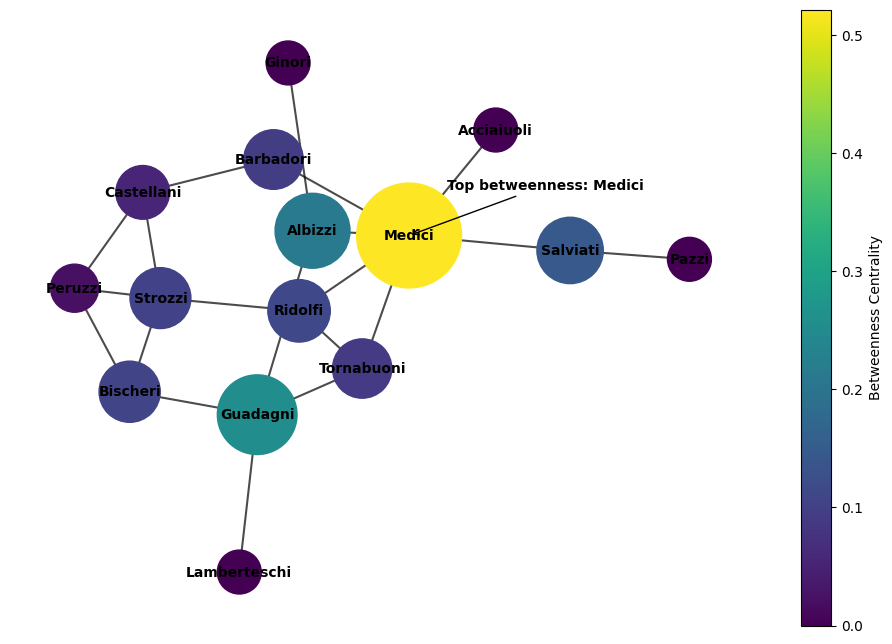

In [26]:
fig, ax = plt.subplots(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

node_sizes = [1000 + 9000 * betweenness_centrality[node] for node in G.nodes()]
node_colors = [betweenness_centrality[node] for node in G.nodes()]

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.viridis,
    ax=ax
)
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.7, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold", ax=ax)

top_node = top_betweenness
x, y = pos[top_node]
ax.annotate(
    f"Top betweenness: {top_node}",
    xy=(x, y),
    xytext=(x + 0.1, y + 0.1),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10,
    fontweight="bold"
)

sm = plt.cm.ScalarMappable(
    cmap=plt.cm.viridis,
    norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors))
)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Betweenness Centrality")

ax.axis("off")
plt.show()

Medici imaju najveći stupanj te imaju najviše veza. Te usput imaju najveću posredničku centralnost što predstavlja najvažniji most između drugih obitelji. Ukazuje na to da je obitelj vrlo ugledna i važna s velikim brojem veza.

Posrednička centralnost opisuje koliko je čvor važan kao most. Blizinska centralnost opisuje koliko je čvor blizu ostalim čvorovima u mreži. Svojstvena centralnost opisuje da važnost čvora ovisi o tome s kim je povezan. PageRank opisuje da jhe čvor važan ako je povezan s važnim čvorovima.